# Notebook 03 - Cointegration and unit-root analysis

This notebook tests whether the core market series share a long-run equilibrium, and whether the deadline structure distorts that result. It works from the fixed input market_data.csv. It runs unit-root tests on the level series under both clock-time and tick-time sampling, runs Engle-Granger cointegration with and without a deadline trend, and quantifies how strongly each series drifts with time-to-kick-off.

The motivation is that a shared deterministic countdown can make standard cointegration tests report a relationship where the shared movement is driven by the clock rather than a genuine stochastic equilibrium. To reproduce, place market_data.csv at ../data/raw/ and run all cells in order. Outputs are written to ../outputs/03_cointegration_analysis/.

## Code attribution

Library-provided algorithms in this notebook: the Augmented Dickey-Fuller unit-root test (statsmodels.tsa.stattools.adfuller), the Engle-Granger cointegration test with MacKinnon critical values (statsmodels.tsa.stattools.coint), and ordinary least squares (statsmodels.api.OLS). pandas, NumPy, Matplotlib and Seaborn are used as standard tooling.

## 1. Configuration and reproducibility

Fixes the random seed, resolves the input path (and stops early if the file is missing), creates the output folders, and writes a run-metadata file.

In [1]:
"""
Notebook 03 - Cointegration and unit-root analysis.

Tests the integration order of the level series (clock-time vs tick-time),
runs Engle-Granger cointegration with and without a deadline trend, and
quantifies deadline drift. Outputs feed Tables 5.2-5.4 and the rolling-beta
figure in Chapter 5.

This cell sets paths, fixes the random seed, creates the output directories,
and writes a run-metadata file for reproducibility.
"""

import os
import sys
import json
from pathlib import Path
from datetime import datetime, timezone
import random
import numpy as np

# Fixed seed for reproducibility across runs
SEED = 42
NOTEBOOK_NAME = "03_cointegration_analysis"

random.seed(SEED)
np.random.seed(SEED)

# Raw tick data (see README for the expected schema)
DATA_PATH = Path("../data/raw/market_data.csv")

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Data file not found at: {DATA_PATH.resolve()}\n"
        "Place market_data.csv in ../data/raw/ (see README)."
    )

# Output directories: figures, tables, and intermediate data
OUTPUT_DIR = Path(f"../outputs/{NOTEBOOK_NAME}")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_OUT_DIR = OUTPUT_DIR / "data" 

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Run metadata written alongside outputs for traceability
metadata = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "notebook": NOTEBOOK_NAME,
    "seed": SEED,
    "python_version": sys.version.split()[0],
    "data_file": DATA_PATH.name
}

with open(OUTPUT_DIR / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Random seed: {SEED}")

Data path: ..\data\raw\market_data.csv
Output directory: ..\outputs\03_cointegration_analysis
Random seed: 42


## 2. Libraries and plot settings

The analysis stack plus the statsmodels ADF and cointegration functions, and the global plot and display settings.

In [2]:
"""Library imports (including statsmodels ADF and cointegration) and plot settings."""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

# Plot defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

# Show all columns, 4 decimal places
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 3. Constants

The three core markets and their short codes used in the output tables.

In [3]:
"""Core markets analysed and their short codes used in output tables."""

CORE_MARKETS = [
    "Match Odds",
    "Over/Under 2.5 Goals",
    "Both teams to Score?"
]

# Long market name -> short code (MO, OU25, BTTS)
MARKET_CODE_MAP = {
    "Match Odds": "MO",
    "Over/Under 2.5 Goals": "OU25",
    "Both teams to Score?": "BTTS"
}

## 4. Output helpers

save_figure and save_table write each figure and table to known file paths in both screen and write-up formats.

In [4]:
"""Output helpers: save figures as PNG/PDF and tables as CSV/LaTeX."""

def save_figure(name, fig=None):
    """Save the current figure as both PNG and PDF."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig = fig or plt.gcf()

    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"

    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved: {png_path.name}, {pdf_path.name}")
    return png_path, pdf_path


def save_table(df, name, index=False):
    """Save a DataFrame as both CSV and a LaTeX table (4 decimal places)."""
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

    csv_path = TABLE_DIR / f"{name}.csv"
    tex_path = TABLE_DIR / f"{name}.tex"

    df.to_csv(csv_path, index=index)
    df.to_latex(tex_path, index=index, float_format="%.4f")

    print(f"Saved: {csv_path.name}, {tex_path.name}")
    return csv_path, tex_path

## 5. Loading the data

load_and_filter_time reads the CSV, checks the required columns, parses timestamps as UTC, keeps pre-match rows, computes time-to-kick-off, and restricts to the final 360 minutes.

In [5]:
def load_and_filter_time(path: Path, min_tau: float = 0, max_tau: float = 360) -> pd.DataFrame:
    """
    Load the raw tick data and restrict to pre-match observations within
    [min_tau, max_tau] minutes to kick-off.
    """
    print(">> Loading Data...")
    df_raw = pd.read_csv(path)

    # Required columns must be present
    required_cols = {"ts_utc", "market_time", "event_id"}
    missing = required_cols - set(df_raw.columns)
    if missing:
        raise ValueError(
            f"Input data is missing required columns: {sorted(missing)}. "
            f"Found columns: {list(df_raw.columns)}"
        )

    df = df_raw.copy()

    # Parse timestamps; unparseable rows become NaT
    df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True, errors="coerce")
    df["market_time"] = pd.to_datetime(df["market_time"], utc=True, errors="coerce")

    # Drop rows with timestamps that failed to parse
    df = df.dropna(subset=["ts_utc", "market_time"])

    # Keep pre-match rows only (quote time before kick-off)
    df = df[df["ts_utc"] < df["market_time"]].copy()

    # tau = minutes from quote time to kick-off
    df["tau_minutes"] = (df["market_time"] - df["ts_utc"]).dt.total_seconds() / 60.0

    # Restrict to the analysis window
    df = df[df["tau_minutes"].between(min_tau, max_tau)].copy()

    if df.empty:
        raise ValueError(
            "Filtered dataset is empty"
        )

    print(">> Done.")
    print("   rows:", df.shape[0], "| events:", df["event_id"].nunique())
    return df

## 6. Building the log-odds panel

robust_log_odds_prob_panel turns one event's ticks into a clean one-minute log-odds panel, with zero prices set to missing before the forward-fill and a spread filter applied in odds space.

In [6]:
def robust_log_odds_prob_panel(
    df_event,
    max_gap_mins=5,
    max_spread_pct=0.20,
    bar_freq="1min"
):
    """
    Turn raw ticks for a single event into a clean log-odds-prob panel.

    Forward-fill represents the standing quote state. Zero prices are set to
    NaN before the forward-fill so they are not carried forward as real quotes.
    The spread filter is applied in odds space; the output is log-odds-prob.
    """

    # Sort by timestamp
    df = df_event.copy()
    df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True, errors="coerce")
    df = df.dropna(subset=["ts_utc"]).sort_values("ts_utc")

    # One column per market/selection
    df["series_id"] = df["market_name"] + "___" + df["selection_name"]

    # Pivot ticks into a wide panel of back/lay prices
    df_pivot = df.pivot_table(
        index="ts_utc",
        columns="series_id",
        values=["best_back_price", "best_lay_price"],
        aggfunc="last"
    )

    # Resample to bars; set zeros to NaN before forward-filling the standing quote
    df_last = df_pivot.resample(bar_freq).last()
    df_last = df_last.replace(0, np.nan)
    df_bars = df_last.ffill()

    # Back and lay sides
    back_df = df_bars["best_back_price"]
    lay_df  = df_bars["best_lay_price"]

    # Both sides must be present
    valid_quotes = back_df.notna() & lay_df.notna()

    # Spread filter relative to back price
    spread = lay_df - back_df
    spread_pct = spread / back_df
    tight_spread = spread_pct < max_spread_pct

    # Mid in odds space, kept only where the bar passes both filters
    mid_odds = (back_df + lay_df) / 2.0
    mid_odds = mid_odds.where(valid_quotes & tight_spread)

    # Implied probability, clipped off the {0,1} boundary, then log-odds-prob
    probs = 1.0 / mid_odds
    epsilon = 1e-4
    probs_clipped = probs.clip(lower=epsilon, upper=1 - epsilon)
    log_odds_prob = np.log(probs_clipped / (1 - probs_clipped))

    return log_odds_prob.dropna(how="all")

## 7. The Engle-Granger cointegration test

run_engle_granger_pair runs the two-step cointegration test: the test itself uses the statsmodels coint function, the OLS step is kept only to report the descriptive long-run coefficients. batch_test_cointegration runs this across a list of pairs. The data is loaded once here for the rest of the notebook.

In [7]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

def run_engle_granger_pair(series_y, series_x):
    """
    Engle-Granger 2-step cointegration test.
    H0: no cointegration (residuals have a unit root).
    H1: cointegration (residuals are stationary).
    """
    # OLS fit to get the descriptive long-run coefficients
    X = sm.add_constant(series_x)
    results = sm.OLS(series_y, X).fit()
    beta = results.params.iloc[1]
    const = results.params.iloc[0]
    residuals = results.resid

    # Cointegration test with constant, using MacKinnon critical values
    t_stat, p_value, crit = coint(series_y, series_x, trend='c')

    return {
        'beta': beta,
        'constant': const,
        't_stat': t_stat,
        'p_value': p_value,
        'crit_1%': crit[0],
        'crit_5%': crit[1],
        'n_obs': len(residuals)
    }


def batch_test_cointegration(df_log_odds_prob_panel, pairs_to_test):
    """Run the Engle-Granger test for a list of pairs on one event's panel."""
    results_list = []

    for y_name, x_name in pairs_to_test:
        # Both series must be in the panel
        if y_name not in df_log_odds_prob_panel.columns or x_name not in df_log_odds_prob_panel.columns:
            print(f"Skipping pair: {y_name} or {x_name} not found.")
            continue

        # Align on shared timestamps (drop NaNs)
        sub_df = df_log_odds_prob_panel[[y_name, x_name]].dropna()

        # Minimum overlap required
        if len(sub_df) < 30:
            print(f"Skipping pair {y_name} vs {x_name}: Insufficient overlap ({len(sub_df)})")
            continue

        try:
            res = run_engle_granger_pair(sub_df[y_name], sub_df[x_name])
            res['series_y'] = y_name
            res['series_x'] = x_name
            results_list.append(res)
        except Exception as e:
            print(f"Error pair {y_name} vs {x_name}: {e}")

    return pd.DataFrame(results_list)

# Load ticks once for all subsequent stages
df = load_and_filter_time(DATA_PATH, min_tau=0, max_tau=360)
unique_events = df['event_id'].unique()
print(f"Loaded {len(unique_events)} events for cointegration analysis.")

>> Loading Data...
>> Done.
   rows: 11384468 | events: 290
Loaded 290 events for cointegration analysis.


## 8. Unit-root test under clock-time sampling

batch_individual_adf_test runs an ADF test on each raw log-odds level series, using one-minute (clock-time) bars, to check whether the series are non-stationary. The summary reports the share of series across events that fail to reject the unit-root null.

In [8]:
def batch_individual_adf_test(df_raw, events, bar_freq='1min'):
    """
    Run ADF on each raw log-odds-prob level series to test for a unit root,
    using clock-time (1-min) bars.
    """
    results_list = []

    # Series tested for integration order
    series_to_check = [
        'Match Odds___The Draw', 
        'Over/Under 2.5 Goals___Under 2.5 Goals',
        'Over/Under 2.5 Goals___Over 2.5 Goals', 
        'Both teams to Score?___Yes'
    ]

    print(f"Running I(1) checks on {len(events)} events...")

    for event_id in events:
        try:
            df_match = df_raw[df_raw['event_id'] == event_id].copy()
            panel = robust_log_odds_prob_panel(df_match, bar_freq=bar_freq)

            # Skip events with too few bars for a reliable ADF
            if len(panel) < 50:
                continue

            row = {'event_id': event_id}

            for col in series_to_check:
                if col in panel.columns:
                    # Augmented Dickey-Fuller unit-root test, intercept only. H0: unit root (p > 0.05 => I(1)).
                    adf_res = adfuller(panel[col].dropna(), autolag='AIC', regression='c')
                    row[col + '_p_value'] = adf_res[1]

            results_list.append(row)

        except Exception:
            continue

    return pd.DataFrame(results_list)

#  Execution 
unique_events = df['event_id'].unique()

df_i1_results = batch_individual_adf_test(df, unique_events)

# Summary - share of series classified as non-stationary (p > 0.05) -
print("\n- I(1) VALIDATION SUMMARY -")
for col in df_i1_results.columns:
    if 'p_value' in col:
        # Count series that fail to reject the unit-root null
        non_stationary_count = (df_i1_results[col] > 0.05).sum()
        total = df_i1_results[col].notna().sum()
        pct = (non_stationary_count / total) * 100

        print(f"{col}:")
        print(f"   Non-Stationary (I(1)) Rate: {pct:.1f}% ({non_stationary_count}/{total})")

i1_summary = pd.DataFrame([
    {
        "series": col.replace("_p_value",""),
        "nonstationary_rate": (df_i1_results[col] > 0.05).mean(),
        "N": df_i1_results[col].notna().sum()
    }
    for col in df_i1_results.columns if "p_value" in col
])
save_table(i1_summary, "tab_i1_validation_clock_time", index=False)

Running I(1) checks on 290 events...

- I(1) VALIDATION SUMMARY -
Match Odds___The Draw_p_value:
   Non-Stationary (I(1)) Rate: 50.7% (147/290)
Over/Under 2.5 Goals___Under 2.5 Goals_p_value:
   Non-Stationary (I(1)) Rate: 46.6% (135/290)
Over/Under 2.5 Goals___Over 2.5 Goals_p_value:
   Non-Stationary (I(1)) Rate: 52.1% (151/290)
Both teams to Score?___Yes_p_value:
   Non-Stationary (I(1)) Rate: 21.0% (61/290)
Saved: tab_i1_validation_clock_time.csv, tab_i1_validation_clock_time.tex


(WindowsPath('../outputs/03_cointegration_analysis/tables/tab_i1_validation_clock_time.csv'),
 WindowsPath('../outputs/03_cointegration_analysis/tables/tab_i1_validation_clock_time.tex'))

## 9. Unit-root test under tick-time sampling

batch_tick_adf_test runs the same ADF test but on tick bars (sampling every Nth market update rather than every minute), to check whether sampling by activity rather than clock time changes the integration-order result. A tick size of 20 is used to keep enough sampled points per event.

In [9]:
def batch_tick_adf_test(df_raw, events, tick_size=50):
    """
    Run ADF on tick bars (operational time) to test whether sampling by
    market updates rather than clock time changes the integration-order result.
    """
    results_list = []

    # Same series as the clock-time test
    series_to_check = [
        'Match Odds___The Draw', 
        'Over/Under 2.5 Goals___Under 2.5 Goals',
        'Over/Under 2.5 Goals___Over 2.5 Goals', 
        'Both teams to Score?___Yes'
    ]

    print(f"Running Tick-Bar ADF checks on {len(events)} events (Tick Size={tick_size})...")

    for i, event_id in enumerate(events):
        if i % 50 == 0: 
            print(f"... processing event {i} of {len(events)}")

        try:
            # Event ticks, sorted by timestamp
            df_match = df_raw[df_raw['event_id'] == event_id].copy()
            df_match["ts_utc"] = pd.to_datetime(df_match["ts_utc"], utc=True, errors="coerce")
            df_match = df_match.dropna(subset=["ts_utc"]).sort_values("ts_utc")

            # One column per market/selection
            df_match['series_id'] = df_match['market_name'] + "___" + df_match['selection_name']

            # Pivot tick-by-tick, last value per timestamp handles bursts
            df_pivot = df_match.pivot_table(
                index='ts_utc', 
                columns='series_id', 
                values=['best_back_price', 'best_lay_price'],
                aggfunc='last'
            )

            df_pivot = df_pivot.replace(0, np.nan).ffill()

            # Operational-time sampling
            df_tick_panel = df_pivot.iloc[::tick_size].copy()

            # log-odds-prob on the tick-sampled panel
            back_df = df_tick_panel['best_back_price']
            lay_df = df_tick_panel['best_lay_price']

            mid_odds = (back_df + lay_df) / 2

            # Both sides must be present
            valid = (back_df.notna()) & (lay_df.notna())
            mid_odds = mid_odds.where(valid)

            epsilon = 1e-4
            probs = 1.0 / mid_odds
            probs_clipped = probs.clip(lower=epsilon, upper=1-epsilon)
            panel_log = np.log(probs_clipped / (1 - probs_clipped))

            # ADF per series on the tick-sampled levels
            row = {'event_id': event_id}
            for col in series_to_check:
                if col in panel_log.columns:
                    series = panel_log[col].dropna()
                    # Need enough ticks for a reliable ADF
                    if len(series) > 30: 
                        # H0: unit root (p > 0.05 => I(1)).
                        adf_res = adfuller(series, autolag='AIC', regression='c')
                        row[col + '_p_value'] = adf_res[1]

            results_list.append(row)

        except Exception:
            continue

    return pd.DataFrame(results_list)

# Execution tick_size=20 to keep enough sampled points per event
df_tick_results = batch_tick_adf_test(df, unique_events, tick_size=20)

# Summary - share of series classified as non-stationary under tick time
print("\n- I(1) VALIDATION SUMMARY (Operational Time / Tick Bars) -")
print(f"Comparing against previous Clock-Time results...")

for col in df_tick_results.columns:
    if 'p_value' in col:
        non_stationary_count = (df_tick_results[col] > 0.05).sum()
        total = df_tick_results[col].notna().sum()
        pct = (non_stationary_count / total) * 100

        print(f"{col}:")
        print(f"   Tick-Time I(1) Rate: {pct:.1f}% ({non_stationary_count}/{total})")

tick_i1_summary = pd.DataFrame([
    {
        "series": col.replace("_p_value",""),
        "nonstationary_rate": (df_tick_results[col] > 0.05).mean(),
        "N": df_tick_results[col].notna().sum()
    }
    for col in df_tick_results.columns if "p_value" in col
])
save_table(tick_i1_summary, "tab_i1_validation_tick_time", index=False)

Running Tick-Bar ADF checks on 290 events (Tick Size=20)...
... processing event 0 of 290
... processing event 50 of 290
... processing event 100 of 290
... processing event 150 of 290
... processing event 200 of 290
... processing event 250 of 290

- I(1) VALIDATION SUMMARY (Operational Time / Tick Bars) -
Comparing against previous Clock-Time results...
Match Odds___The Draw_p_value:
   Tick-Time I(1) Rate: 0.3% (1/290)
Over/Under 2.5 Goals___Under 2.5 Goals_p_value:
   Tick-Time I(1) Rate: 0.3% (1/290)
Over/Under 2.5 Goals___Over 2.5 Goals_p_value:
   Tick-Time I(1) Rate: 2.1% (6/290)
Both teams to Score?___Yes_p_value:
   Tick-Time I(1) Rate: 5.9% (17/290)
Saved: tab_i1_validation_tick_time.csv, tab_i1_validation_tick_time.tex


(WindowsPath('../outputs/03_cointegration_analysis/tables/tab_i1_validation_tick_time.csv'),
 WindowsPath('../outputs/03_cointegration_analysis/tables/tab_i1_validation_tick_time.tex'))

## 10. Preconditions against the cointegration outcome

check_i1_and_coint reports, for one pair on one event, whether each level series is non-stationary and whether the pair is cointegrated. The batch then cross-tabulates the precondition (both series non-stationary) against the cointegration outcome, and computes a pooled false-positive rate: the share of pair-event tests where cointegration is reported even though the both-non-stationary precondition fails.

In [10]:
def check_i1_and_coint(df_panel, y_col, x_col):
    """
    For one pair on one event, return:
      - y_i1 / x_i1: whether each level series is non-stationary (ADF p > 0.05 => I(1))
      - is_coint:    whether the pair is cointegrated (Engle-Granger coint p < 0.05)
    """
    sub = df_panel[[y_col, x_col]].dropna()
    if len(sub) < 30:
        return None

    # ADF on each level series. Null: unit root. p > 0.05 => fail to reject => I(1).
    adf_y = adfuller(sub[y_col], autolag='AIC', regression='c')[1]
    adf_x = adfuller(sub[x_col], autolag='AIC', regression='c')[1]
    y_i1 = adf_y > 0.05
    x_i1 = adf_x > 0.05

    # Engle-Granger cointegration test (correct MacKinnon criticals). Null: no cointegration.
    eg_t, eg_p, eg_crit = coint(sub[y_col], sub[x_col], trend='c')
    is_coint = eg_p < 0.05

    return {'y_i1': y_i1, 'x_i1': x_i1, 'is_coint': is_coint, 'eg_p_value': eg_p}


# Do the I(1) preconditions hold where Engle-Granger reports cointegration
thesis_pairs = [
    ("Match Odds___The Draw", "Over/Under 2.5 Goals___Under 2.5 Goals"),
    ("Over/Under 2.5 Goals___Over 2.5 Goals", "Both teams to Score?___Yes"),
]

results_all_pairs = []
unique_events = df["event_id"].unique()
print(f"Testing I(1) preconditions vs EG outcome on {len(unique_events)} events...")

for pair_idx, (Y_NAME, X_NAME) in enumerate(thesis_pairs, start=1):
    results = []
    for event_id in unique_events:
        try:
            df_match = df[df['event_id'] == event_id].copy()
            panel = robust_log_odds_prob_panel(df_match, bar_freq='1min')
            if Y_NAME in panel.columns and X_NAME in panel.columns:
                res = check_i1_and_coint(panel, Y_NAME, X_NAME)
                if res:
                    res['event_id'] = event_id
                    res["series_y"] = Y_NAME
                    res["series_x"] = X_NAME
                    results.append(res)
        except Exception:
            continue

    df_res = pd.DataFrame(results)
    if df_res.empty:
        print(f"\nNo results for pair {Y_NAME} vs {X_NAME}.")
        continue

    # Precondition: both series I(1)
    df_res["both_I1"] = df_res["y_i1"] & df_res["x_i1"]

    # Cross-tabulate precondition against cointegration outcome
    tab = pd.crosstab(
        df_res["both_I1"], df_res["is_coint"],
        rownames=["Both I(1)"], colnames=["EG cointegrated (p<0.05)"]
    )
    print(f"\nPair {pair_idx}: {Y_NAME} vs {X_NAME}")
    print(tab)

    save_table(tab.reset_index(), f"tab_i1_preconditions_vs_eg_outcome__pair_{pair_idx}", index=False)
    results_all_pairs.append(df_res)

# Pooled false-positive rate across all pairs 
df_precond_all = pd.concat(results_all_pairs, ignore_index=True) if results_all_pairs else pd.DataFrame()
if df_precond_all.empty:
    raise ValueError("No precondition/cointegration results were computed across pairs.")

# Cointegration false-positive rate. A false positive is a pair-event where cointegration is reported although the both-I(1)
# precondition fails - used to quantify how often the levels tests mislead.
df_precond_all["false_positive"] = df_precond_all["is_coint"] & (~df_precond_all["both_I1"])
fp_n = int(df_precond_all["false_positive"].sum())
total_n = len(df_precond_all)
fp_rate = fp_n / total_n

print("\n- POOLED FALSE-POSITIVE SUMMARY (ALL PAIRS) -")
print(f"EG false-positive rate (pass despite failing 'both I(1)'): {fp_rate:.1%} ({fp_n}/{total_n} pair-event tests)")

Testing I(1) preconditions vs EG outcome on 290 events...

Pair 1: Match Odds___The Draw vs Over/Under 2.5 Goals___Under 2.5 Goals
EG cointegrated (p<0.05)  False  True 
Both I(1)                             
False                        69    136
True                         44     41
Saved: tab_i1_preconditions_vs_eg_outcome__pair_1.csv, tab_i1_preconditions_vs_eg_outcome__pair_1.tex

Pair 2: Over/Under 2.5 Goals___Over 2.5 Goals vs Both teams to Score?___Yes
EG cointegrated (p<0.05)  False  True 
Both I(1)                             
False                        92    146
True                         31     21
Saved: tab_i1_preconditions_vs_eg_outcome__pair_2.csv, tab_i1_preconditions_vs_eg_outcome__pair_2.tex

- POOLED FALSE-POSITIVE SUMMARY (ALL PAIRS) -
EG false-positive rate (pass despite failing 'both I(1)'): 48.6% (282/580 pair-event tests)


## 11. Deadline-trend regression function

analyze_deadline_trend regresses each log-odds series on time-to-kick-off to quantify deadline drift, returning the R-squared, the slope, and whether the slope is significant for each series.

In [11]:
import statsmodels.api as sm

def analyze_deadline_trend(df_log_odds_prob_panel, df_raw_metadata):
    """
    Regress each log-odds-prob series on time-to-kick-off (tau) to quantify
    deadline drift:  logodds_prob = alpha + beta*tau + e.
    Returns R^2, the tau slope, and slope significance per series.
    """
    market_time = pd.to_datetime(df_raw_metadata["market_time"].iloc[0], utc=True, errors="coerce")
    if pd.isna(market_time):
        raise ValueError("market_time could not be parsed for this event.")

    results = []
    for col in df_log_odds_prob_panel.columns:
        y = df_log_odds_prob_panel[col].dropna()
        if len(y) < 30:
            continue

        # tau = minutes remaining to kick-off at each timestamp
        ts = y.index
        tau = (market_time - ts).total_seconds() / 60.0

        X = sm.add_constant(tau)
        try:
            model = sm.OLS(y, X).fit()
            results.append({
                'Series': col,
                'R_squared': model.rsquared,
                'Beta_Time': model.params.iloc[1],
                'Is_Trending': model.pvalues.iloc[1] < 0.05
            })
        except Exception:
            continue

    return pd.DataFrame(results)

## 12. Deadline-trend batch and summary

Runs the deadline-trend regression across every event, splits the series label into market and selection, and summarises the drift by market both at the series level and event-weighted. It saves the summary tables and a boxplot of event-level mean R-squared by market.

Running deadline-trend batch on 290 events (bar_freq=1min)...
... event 0 / 290
... event 50 / 290
... event 100 / 290
... event 150 / 290
... event 200 / 290
... event 250 / 290
(2030, 5)
                      n_series  mean_R2  median_R2  pct_trending  mean_beta
Market                                                                     
Match Odds                 870   0.2359     0.1780        0.8517     0.0000
Over/Under 2.5 Goals       580   0.2183     0.1373        0.8448    -0.0000
Both teams to Score?       580   0.1298     0.0591        0.7655    -0.0000
                      events  mean_event_R2  median_event_R2  \
Market                                                         
Match Odds               290         0.2359           0.2049   
Over/Under 2.5 Goals     290         0.2183           0.1421   
Both teams to Score?     290         0.1298           0.0759   

                      mean_event_pct_trending  
Market                                         
Match Odds    

C:\Users\cdye\AppData\Local\Temp\ipykernel_37728\2319672214.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=markets, showfliers=False)


Saved: fig_deadline_trend_r2_boxplot.png, fig_deadline_trend_r2_boxplot.pdf


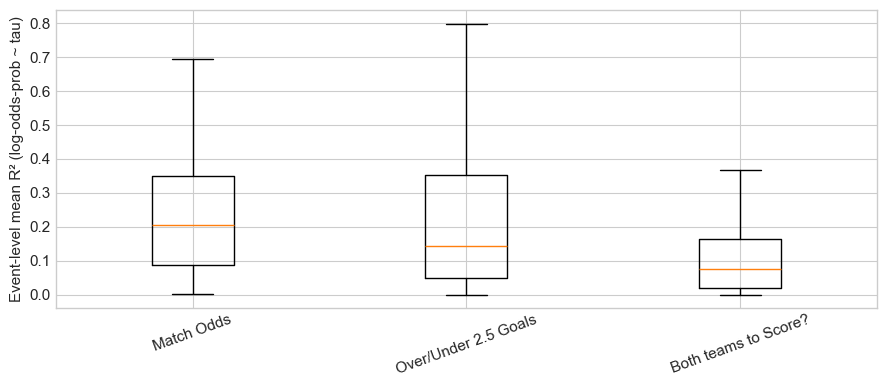

In [12]:
CORE_MARKETS = [
    "Match Odds",
    "Over/Under 2.5 Goals",
    "Both teams to Score?"
]

def batch_deadline_trend(
    df_all: pd.DataFrame,
    *,
    bar_freq: str = "1min",
    max_spread_pct: float = 0.20,
    core_markets: list[str] | None = CORE_MARKETS,
    min_obs: int = 30,
    verbose_every: int = 50
) -> pd.DataFrame:
    """
    For each event: build the log-odds-prob panel, regress each series on tau,
    and collect R^2 and slope significance. Returns one row per (event, series).
    """
    out = []
    event_ids = df_all["event_id"].unique()

    print(f"Running deadline-trend batch on {len(event_ids)} events (bar_freq={bar_freq})...")

    for i, eid in enumerate(event_ids):
        if verbose_every and i % verbose_every == 0:
            print(f"... event {i} / {len(event_ids)}")

        df_evt = df_all[df_all["event_id"] == eid].copy()
        if core_markets is not None:
            df_evt = df_evt[df_evt["market_name"].isin(core_markets)].copy()
        if df_evt.empty:
            continue

        try:
            panel = robust_log_odds_prob_panel(df_evt, bar_freq=bar_freq, max_spread_pct=max_spread_pct)
            if panel.empty:
                continue

            trend = analyze_deadline_trend(panel, df_evt)
            if trend is None or trend.empty:
                continue

            trend = trend.copy()
            trend["event_id"] = eid
            out.append(trend)

        except Exception:
            continue

    if not out:
        return pd.DataFrame(columns=["Series","R_squared","Beta_Time","Is_Trending","event_id"])

    return pd.concat(out, ignore_index=True)

trend_all = batch_deadline_trend(
    df,
    bar_freq="1min",
    max_spread_pct=0.20,
    core_markets=CORE_MARKETS
)

print(trend_all.shape)
trend_all.head()

# Split the series label into market and selection
trend_all["Market"] = trend_all["Series"].str.split("___").str[0]
trend_all["Selection"] = trend_all["Series"].str.split("___").str[1]

# Series-level summary by market
summary_market = (
    trend_all.groupby("Market")
    .agg(
        n_series=("R_squared", "size"),
        mean_R2=("R_squared", "mean"),
        median_R2=("R_squared", "median"),
        pct_trending=("Is_Trending", "mean"),
        mean_beta=("Beta_Time", "mean"),
    )
    .sort_values("mean_R2", ascending=False)
)

print(summary_market)

# Event-level means, then averaged by market (event-weighted summary)
event_market = (
    trend_all.groupby(["event_id", "Market"])
    .agg(
        mean_R2=("R_squared", "mean"),
        pct_trending=("Is_Trending", "mean"),
        mean_beta=("Beta_Time", "mean"),
    )
    .reset_index()
)

summary_event_weighted = (
    event_market.groupby("Market")
    .agg(
        events=("event_id", "nunique"),
        mean_event_R2=("mean_R2", "mean"),
        median_event_R2=("mean_R2", "median"),
        mean_event_pct_trending=("pct_trending", "mean"),
    )
    .sort_values("mean_event_R2", ascending=False)
)

print(summary_event_weighted)

save_table(summary_market.reset_index(), "tab_deadline_trend_by_market", index=False)
save_table(summary_event_weighted.reset_index(), "tab_deadline_trend_event_weighted", index=False)

# Boxplot of event-level mean R^2 by market
import matplotlib.pyplot as plt

markets = summary_event_weighted.index.tolist()
data = [event_market.loc[event_market["Market"] == m, "mean_R2"].dropna().values for m in markets]

plt.figure(figsize=(9, 4))
plt.boxplot(data, labels=markets, showfliers=False)
plt.ylabel("Event-level mean R² (log-odds-prob ~ tau)")
plt.xticks(rotation=20)
plt.tight_layout()

save_figure("fig_deadline_trend_r2_boxplot")

plt.show()

## 13. Standard versus trend-adjusted cointegration

run_engle_granger_with_trend adds a deadline trend to the cointegrating regression and tests cointegration with a constant and linear trend, using the MacKinnon critical values. The cell runs both the standard and trend-adjusted tests across all events, flags where the cointegration verdict flips between the two specifications, and summarises the pass rates and flip rate per pair.

In [13]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

def run_engle_granger_with_trend(series_y, series_x, market_time, min_overlap=30):
    """
    Trend-adjusted Engle-Granger:  Y = const + beta*X + delta*tau + eps.
    The cointegration test uses coint(trend='ct'), so the constant and linear
    trend are handled with the MacKinnon cointegration critical values. The OLS is 
    to report the descriptive long-run coefficients.
    """
    data = pd.DataFrame({"Y": series_y, "X": series_x}).dropna()
    if len(data) < min_overlap:
        return None

    market_time = pd.to_datetime(market_time, utc=True, errors="coerce")
    if pd.isna(market_time):
        return None

    # tau = minutes to kick-off at each timestamp
    ts = data.index
    tau = pd.Series((market_time - ts).total_seconds() / 60.0, index=ts, name="Time")

    # Descriptive long-run fit (reports beta_x, beta_time, R^2)
    exog = sm.add_constant(pd.DataFrame({"X": data["X"], "Time": tau}, index=ts))
    model = sm.OLS(data["Y"], exog).fit()

    # cointegration test with a constant and linear trend
    t_stat, p_value, crit = coint(data["Y"], data["X"], trend="ct")

    return {
        "beta_x": float(model.params["X"]),
        "beta_time": float(model.params["Time"]),
        "constant": float(model.params["const"]),
        "r_squared": float(model.rsquared),
        "t_stat": float(t_stat),
        "p_value": float(p_value),
        "n_obs": int(len(data)),
    }

def batch_test_coint_with_trend(df_log_odds_prob_panel, df_raw_metadata, pairs_to_test, min_overlap=30):
    """Run the trend-adjusted Engle-Granger test for a list of pairs on one event's panel."""
    market_time = df_raw_metadata["market_time"].iloc[0]
    results_list = []
    for y_name, x_name in pairs_to_test:
        if y_name not in df_log_odds_prob_panel.columns or x_name not in df_log_odds_prob_panel.columns:
            continue
        res = run_engle_granger_with_trend(
            df_log_odds_prob_panel[y_name],
            df_log_odds_prob_panel[x_name],
            market_time,
            min_overlap=min_overlap
        )
        if res:
            res["series_y"] = y_name
            res["series_x"] = x_name
            results_list.append(res)
    return pd.DataFrame(results_list)

# Test pairs
pairs = [
    ("Match Odds___The Draw", "Over/Under 2.5 Goals___Under 2.5 Goals"),
    ("Over/Under 2.5 Goals___Over 2.5 Goals", "Both teams to Score?___Yes"),
]

# Standard vs trend-adjusted Engle-Granger across all events
rows = []
for eid in df["event_id"].unique():
    df_evt = df[(df["event_id"] == eid) & (df["market_name"].isin(CORE_MARKETS))].copy()
    if df_evt.empty:
        continue
    try:
        panel = robust_log_odds_prob_panel(df_evt, bar_freq="1min", max_spread_pct=0.20)
        if panel.empty:
            continue
        std = batch_test_cointegration(panel, pairs)
        trn = batch_test_coint_with_trend(panel, df_evt, pairs)
        if std.empty or trn.empty:
            continue
        m = std.merge(trn, on=["series_y", "series_x"], suffixes=("_std", "_trn"))
        m["event_id"] = eid
        rows.append(m)
    except Exception:
        continue

cmp_df = pd.concat(rows, ignore_index=True)

# Pass flags and flip flag (pass under one specification but not the other)
cmp_df["std_pass"] = cmp_df["p_value_std"] < 0.05
cmp_df["trn_pass"] = cmp_df["p_value_trn"] < 0.05
cmp_df["flip"] = cmp_df["std_pass"] != cmp_df["trn_pass"]

# Per-pair pass rates and flip rate
summary = (
    cmp_df.groupby(["series_y", "series_x"])
    .agg(
        tests=("event_id", "size"),
        std_rate=("std_pass", "mean"),
        trn_rate=("trn_pass", "mean"),
        flip_rate=("flip", "mean"),
        mean_beta_std=("beta", "mean"),
        mean_beta_trn=("beta_x", "mean"),
        mean_beta_time=("beta_time", "mean"),
        mean_r2_trn=("r_squared", "mean"),
    )
    .reset_index()
)

print(summary.to_string(index=False))
save_table(summary, "tab_std_vs_trend_comparison", index=False)

                             series_y                               series_x  tests  std_rate  trn_rate  flip_rate  mean_beta_std  mean_beta_trn  mean_beta_time  mean_r2_trn
                Match Odds___The Draw Over/Under 2.5 Goals___Under 2.5 Goals    290    0.6172    0.7379     0.2034         0.1409         0.0991          0.0000       0.2213
Over/Under 2.5 Goals___Over 2.5 Goals             Both teams to Score?___Yes    290    0.5793    0.6655     0.1828         0.2429         0.1550          0.0000       0.2586
Saved: tab_std_vs_trend_comparison.csv, tab_std_vs_trend_comparison.tex


(WindowsPath('../outputs/03_cointegration_analysis/tables/tab_std_vs_trend_comparison.csv'),
 WindowsPath('../outputs/03_cointegration_analysis/tables/tab_std_vs_trend_comparison.tex'))

## 14. Rolling beta over event time

Computes the rolling regression slope between the Match Odds Draw series and the Over/Under Under series for a representative event (the one with the most observations), and plots it against time-to-kick-off alongside the full-sample slope. This shows whether the relationship between the two series is stable through the countdown.

Saved: fig_5_6_rolling_beta.png, fig_5_6_rolling_beta.pdf


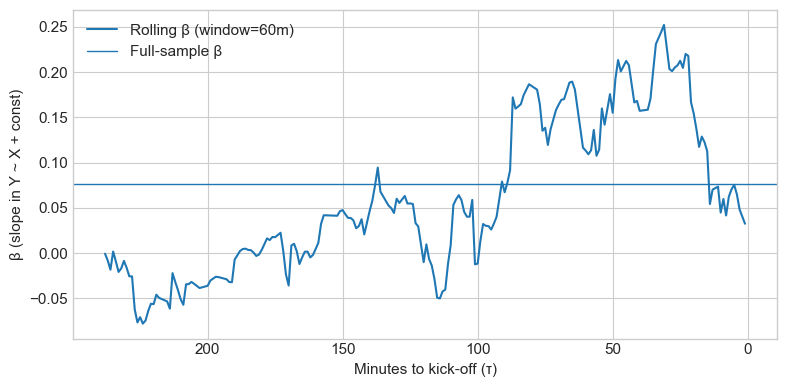

In [14]:
# Rolling beta over event time (tau)


Y_COL = "Match Odds___The Draw"
X_COL = "Over/Under 2.5 Goals___Under 2.5 Goals"
WINDOW = 60  # minutes (on 1-min bars)

# Representative event: the one with the most observations in the core markets
df_core = df[df["market_name"].isin(CORE_MARKETS)].copy()
event_counts = df_core.groupby("event_id").size().sort_values(ascending=False)
rep_event_id = int(event_counts.index[0])

df_evt = df_core[df_core["event_id"] == rep_event_id].copy()
panel = robust_log_odds_prob_panel(df_evt, bar_freq="1min", max_spread_pct=0.20)

# Need at least two windows of overlap
sub = panel[[Y_COL, X_COL]].dropna()
if len(sub) < WINDOW * 2:
    raise ValueError(f"Not enough overlap for rolling beta (event_id={rep_event_id}, n={len(sub)}).")

# tau at each bar
market_time = pd.to_datetime(df_evt["market_time"].iloc[0], utc=True, errors="coerce")
tau = (market_time - sub.index).total_seconds() / 60.0

x = sub[X_COL].astype(float)
y = sub[Y_COL].astype(float)

# Rolling OLS slope: beta = Cov(x, y) / Var(x) over the window
mx = x.rolling(WINDOW).mean()
my = y.rolling(WINDOW).mean()
cov_xy = ((x - mx) * (y - my)).rolling(WINDOW).mean()
var_x  = ((x - mx) ** 2).rolling(WINDOW).mean()
beta_roll = cov_xy / var_x

# Full-sample slope for reference
beta_full = sm.OLS(y, sm.add_constant(x)).fit().params.iloc[1]

plt.figure(figsize=(8, 4))
plt.plot(tau, beta_roll, linewidth=1.5, label=f"Rolling β (window={WINDOW}m)")
plt.axhline(beta_full, linestyle="-", linewidth=1.0, label="Full-sample β")
plt.gca().invert_xaxis()  # countdown: tau decreases toward kick-off
plt.xlabel("Minutes to kick-off (τ)")
plt.ylabel("β (slope in Y ~ X + const)")
plt.legend()
plt.tight_layout()

save_figure("fig_5_6_rolling_beta")
plt.show()

## 15. Synthesis tables

Builds the readable Chapter 5 tables with short labels: the deadline-drift summary by market, the ADF sensitivity comparing clock-time and tick-time non-stationarity rates, and the Engle-Granger standard versus trend-adjusted pass and flip rates. It also prints the pooled false-positive rate.

In [15]:
# Readable synthesis tables


# Short labels 
SHORT_SERIES = {
    "Match Odds___The Draw": "MO:Draw",
    "Over/Under 2.5 Goals___Under 2.5 Goals": "OU25:Under",
    "Over/Under 2.5 Goals___Over 2.5 Goals": "OU25:Over",
    "Both teams to Score?___Yes": "BTTS:Yes",
}

SHORT_MARKET = {
    "Match Odds": "MO",
    "Over/Under 2.5 Goals": "OU25",
    "Both teams to Score?": "BTTS",
}

def map_series(s: str) -> str:
    return SHORT_SERIES.get(s, s)

def map_market(s: str) -> str:
    return SHORT_MARKET.get(s, s)

# Table 5.2: deadline drift summary (market-family level)
drift_tbl = (
    summary_event_weighted.reset_index()
    .rename(columns={
        "mean_event_R2": "Mean event R2",
        "median_event_R2": "Median event R2",
        "mean_event_pct_trending": "Share trending"
    })
)

drift_tbl["Market"] = drift_tbl["Market"].map(map_market)
drift_tbl = drift_tbl[["Market", "Mean event R2", "Median event R2", "Share trending"]].copy()
drift_tbl[["Mean event R2", "Median event R2", "Share trending"]] = drift_tbl[
    ["Mean event R2", "Median event R2", "Share trending"]
].astype(float).round(4)

save_table(drift_tbl, "tab_5_2_deadline_drift", index=False)

# Table 5.3: ADF sensitivity (clock-time vs tick-time I(1) rates)
clock = i1_summary.rename(columns={
    "series": "Series_raw",
    "nonstationary_rate": "I1 rate (clock)",
    "N": "N events"
}).copy()

tick = tick_i1_summary.rename(columns={
    "series": "Series_raw",
    "nonstationary_rate": "I1 rate (tick)"
}).copy()

adf_tbl = (
    clock.merge(tick[["Series_raw", "I1 rate (tick)"]], on="Series_raw", how="inner")
    .assign(Series=lambda d: d["Series_raw"].map(map_series))
)

adf_tbl = adf_tbl[["Series", "I1 rate (clock)", "I1 rate (tick)", "N events"]].copy()
adf_tbl[["I1 rate (clock)", "I1 rate (tick)"]] = adf_tbl[["I1 rate (clock)", "I1 rate (tick)"]].astype(float).round(4)
adf_tbl["N events"] = adf_tbl["N events"].astype(int)

save_table(adf_tbl, "tab_5_3_adf_clock_vs_tick", index=False)

# Table 5.4: Engle-Granger standard vs trend-adjusted (pass and flip rates)
eg_tbl = summary.copy()

eg_tbl["Pair"] = eg_tbl["series_y"].map(map_series) + " vs " + eg_tbl["series_x"].map(map_series)

eg_tbl = eg_tbl[["Pair", "std_rate", "trn_rate", "flip_rate"]].rename(columns={
    "std_rate": "Std pass rate",
    "trn_rate": "Trend pass rate",
    "flip_rate": "Flip rate"
}).copy()

eg_tbl[["Std pass rate", "Trend pass rate", "Flip rate"]] = eg_tbl[
    ["Std pass rate", "Trend pass rate", "Flip rate"]
].astype(float).round(4)

save_table(eg_tbl, "tab_5_4_eg_stress", index=False)

# Pooled Engle-Granger false-positive rate (reported in the writeup)
try:
    print(f"EG false-positive rate (pass but not both I(1) precondition): {fp_rate:.4f}")
except NameError:
    print("fp_rate not found in this run (skip note or re-run the precondition cell).")

# Display the tables in-notebook
drift_tbl, adf_tbl, eg_tbl

Saved: tab_5_2_deadline_drift.csv, tab_5_2_deadline_drift.tex
Saved: tab_5_3_adf_clock_vs_tick.csv, tab_5_3_adf_clock_vs_tick.tex
Saved: tab_5_4_eg_stress.csv, tab_5_4_eg_stress.tex
EG false-positive rate (pass but not both I(1) precondition): 0.4862


(  Market  Mean event R2  Median event R2  Share trending
 0     MO         0.2359           0.2049          0.8517
 1   OU25         0.2183           0.1421          0.8448
 2   BTTS         0.1298           0.0759          0.7655,
        Series  I1 rate (clock)  I1 rate (tick)  N events
 0     MO:Draw           0.5069          0.0034       290
 1  OU25:Under           0.4655          0.0034       290
 2   OU25:Over           0.5207          0.0207       290
 3    BTTS:Yes           0.2103          0.0586       290,
                     Pair  Std pass rate  Trend pass rate  Flip rate
 0  MO:Draw vs OU25:Under         0.6172           0.7379     0.2034
 1  OU25:Over vs BTTS:Yes         0.5793           0.6655     0.1828)